In [40]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score, accuracy_score
)

# ── Reproducibility (UPDATED) ────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # ADD THIS

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()  # ADD THIS

print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Deterministic mode: ON')
print(f'Random seed set: {SEED}')

GPU available: True
Deterministic mode: ON
Random seed set: 42


In [41]:
import kagglehub

path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Path to dataset files:", path)
DATA_DIR = Path(path)

print(DATA_DIR)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Path to dataset files: /kaggle/input/brain-mri-images-for-brain-tumor-detection
/kaggle/input/brain-mri-images-for-brain-tumor-detection


In [42]:
image_paths = []
labels      = []

for class_name in ['yes', 'no']:
    class_dir = DATA_DIR / class_name
    for img_file in class_dir.glob('*'):
        if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
            image_paths.append(str(img_file))
            labels.append(1 if class_name == 'yes' else 0)  # 1 = tumor, 0 = no tumor

print(f'Total images   : {len(image_paths)}')
print(f'Tumor (yes=1)  : {sum(labels)}')
print(f'No Tumor (no=0): {len(labels) - sum(labels)}')

Total images   : 253
Tumor (yes=1)  : 155
No Tumor (no=0): 98


# 1 - Exploratory Data Analysis

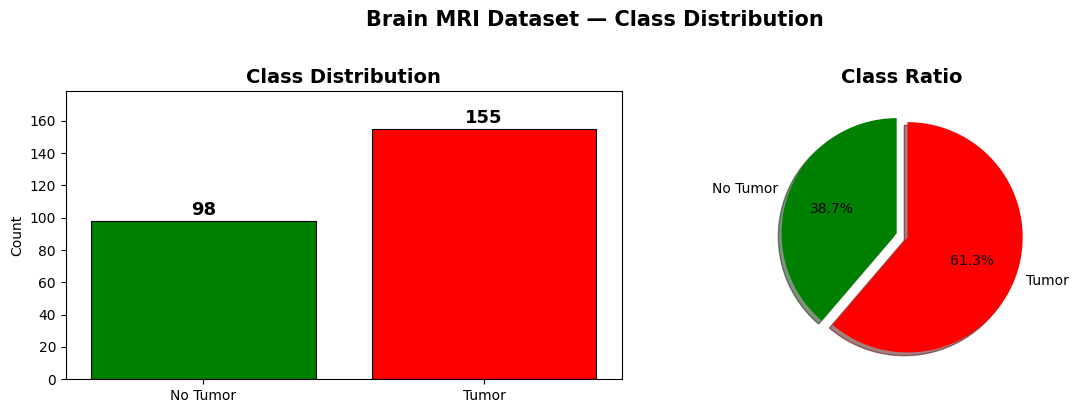

In [43]:
label_names  = ['No Tumor', 'Tumor']
class_counts = Counter(labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bars = axes[0].bar(
    label_names,
    [class_counts[0], class_counts[1]],
    color=['green', 'red'],
    edgecolor='black', linewidth=0.8
)
for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(count), ha='center', va='bottom', fontsize=13, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(class_counts.values()) * 1.15)

axes[1].pie(
    [class_counts[0], class_counts[1]],
    labels=label_names,
    autopct='%1.1f%%',
    colors=['green', 'red'],
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)
axes[1].set_title('Class Ratio', fontsize=14, fontweight='bold')

plt.suptitle('Brain MRI Dataset — Class Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

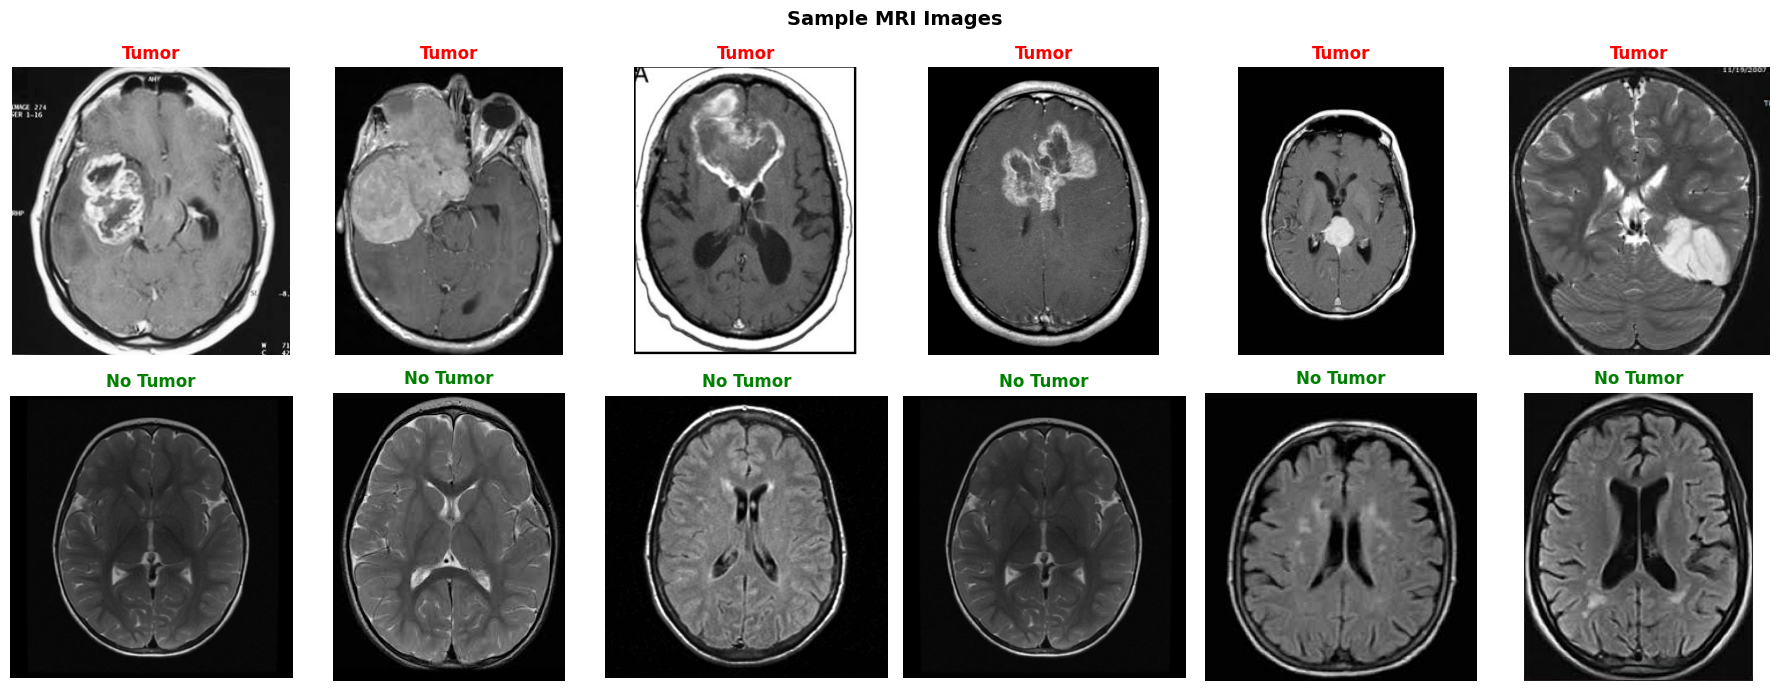

In [44]:
yes_paths = [p for p, l in zip(image_paths, labels) if l == 1]
no_paths  = [p for p, l in zip(image_paths, labels) if l == 0]

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Sample MRI Images',
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes[0]):
    img = Image.open(random.choice(yes_paths)).convert('RGB')
    ax.imshow(img)
    ax.set_title('Tumor', color='red', fontweight='bold')
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    img = Image.open(random.choice(no_paths)).convert('RGB')
    ax.imshow(img)
    ax.set_title('No Tumor', color='green', fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

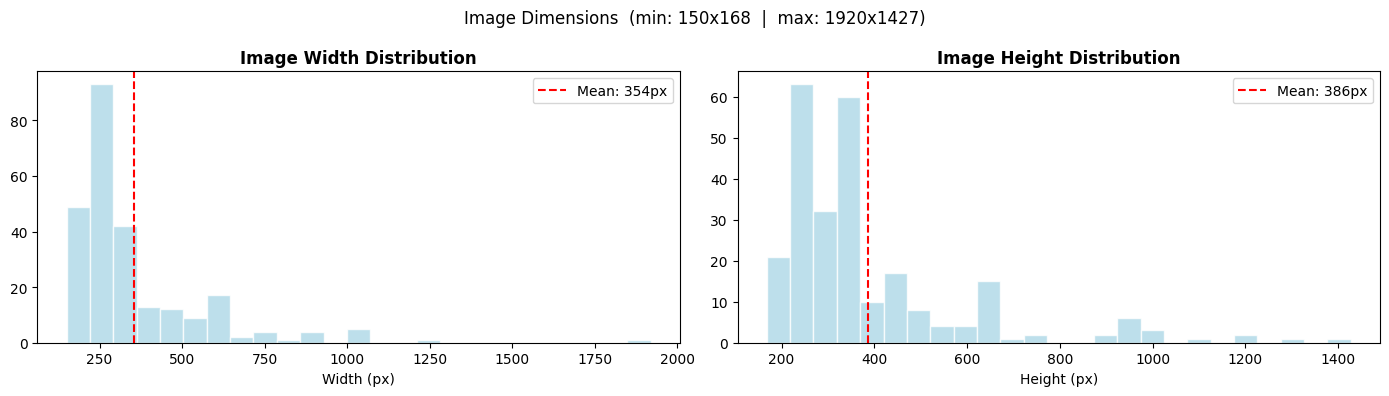

In [45]:
widths, heights = [], []
for p in image_paths:
    with Image.open(p) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(widths, bins=25, color='lightblue', edgecolor='white', alpha=0.8)
axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}px')
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].legend()

axes[1].hist(heights, bins=25, color='lightblue', edgecolor='white', alpha=0.8)
axes[1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}px')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].legend()

plt.suptitle(f'Image Dimensions  (min: {min(widths)}x{min(heights)}  |  max: {max(widths)}x{max(heights)})',
             fontsize=12)
plt.tight_layout()
plt.show()

# 2 - Preprocess & Augmentation

In [46]:
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, labels,
    test_size=0.15, random_state=42, stratify=labels
)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_train_paths, y_train,
    test_size=0.1765, random_state=42, stratify=y_train
)

print(f'Train: {len(X_train_paths)} images  (tumor: {sum(y_train)}, no-tumor: {len(y_train)-sum(y_train)})')
print(f'Val: {len(X_val_paths)} images  (tumor: {sum(y_val)}, no-tumor: {len(y_val)-sum(y_val)})')
print(f'Test: {len(X_test_paths)} images  (tumor: {sum(y_test)}, no-tumor: {len(y_test)-sum(y_test)})')

Train: 177 images  (tumor: 109, no-tumor: 68)
Val: 38 images  (tumor: 23, no-tumor: 15)
Test: 38 images  (tumor: 23, no-tumor: 15)


In [47]:
def load_images(paths, labels_list, img_size=224):
    X, y = [], []
    for p, label in zip(paths, labels_list):
        img = Image.open(p).convert('RGB').resize((img_size, img_size))
        X.append(np.array(img))
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print('Loading images..')
X_train, y_train_arr = load_images(X_train_paths, y_train)
X_val,   y_val_arr   = load_images(X_val_paths,   y_val)
X_test,  y_test_arr  = load_images(X_test_paths,  y_test)

print(f'X_train shape: {X_train.shape}')
print(f'X_val   shape: {X_val.shape}')
print(f'X_test  shape: {X_test.shape}')

Loading images..
X_train shape: (177, 224, 224, 3)
X_val   shape: (38, 224, 224, 3)
X_test  shape: (38, 224, 224, 3)


In [48]:
from tensorflow.keras.applications import vgg16, resnet50, efficientnet, mobilenet_v2

# NOTE: vertical_flip removed — brain MRI has clear top/bottom orientation.
# brightness_range tightened to avoid extreme shifts on small dataset.
_AUG_PARAMS = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    horizontal_flip=True,
    fill_mode='nearest'
)

aug_cnn = ImageDataGenerator(**_AUG_PARAMS, rescale=1./255)

# NOTE: efficientnet.preprocess_input is a no-op in tf.keras — the model has a
# built-in Normalization layer and expects raw [0, 255] input. Keeping it for clarity.
aug_vgg    = ImageDataGenerator(**_AUG_PARAMS, preprocessing_function=vgg16.preprocess_input)
aug_resnet = ImageDataGenerator(**_AUG_PARAMS, preprocessing_function=resnet50.preprocess_input)
aug_eff    = ImageDataGenerator(**_AUG_PARAMS, preprocessing_function=efficientnet.preprocess_input)
aug_mob    = ImageDataGenerator(**_AUG_PARAMS, preprocessing_function=mobilenet_v2.preprocess_input)

test_datagen = ImageDataGenerator(rescale=1./255)


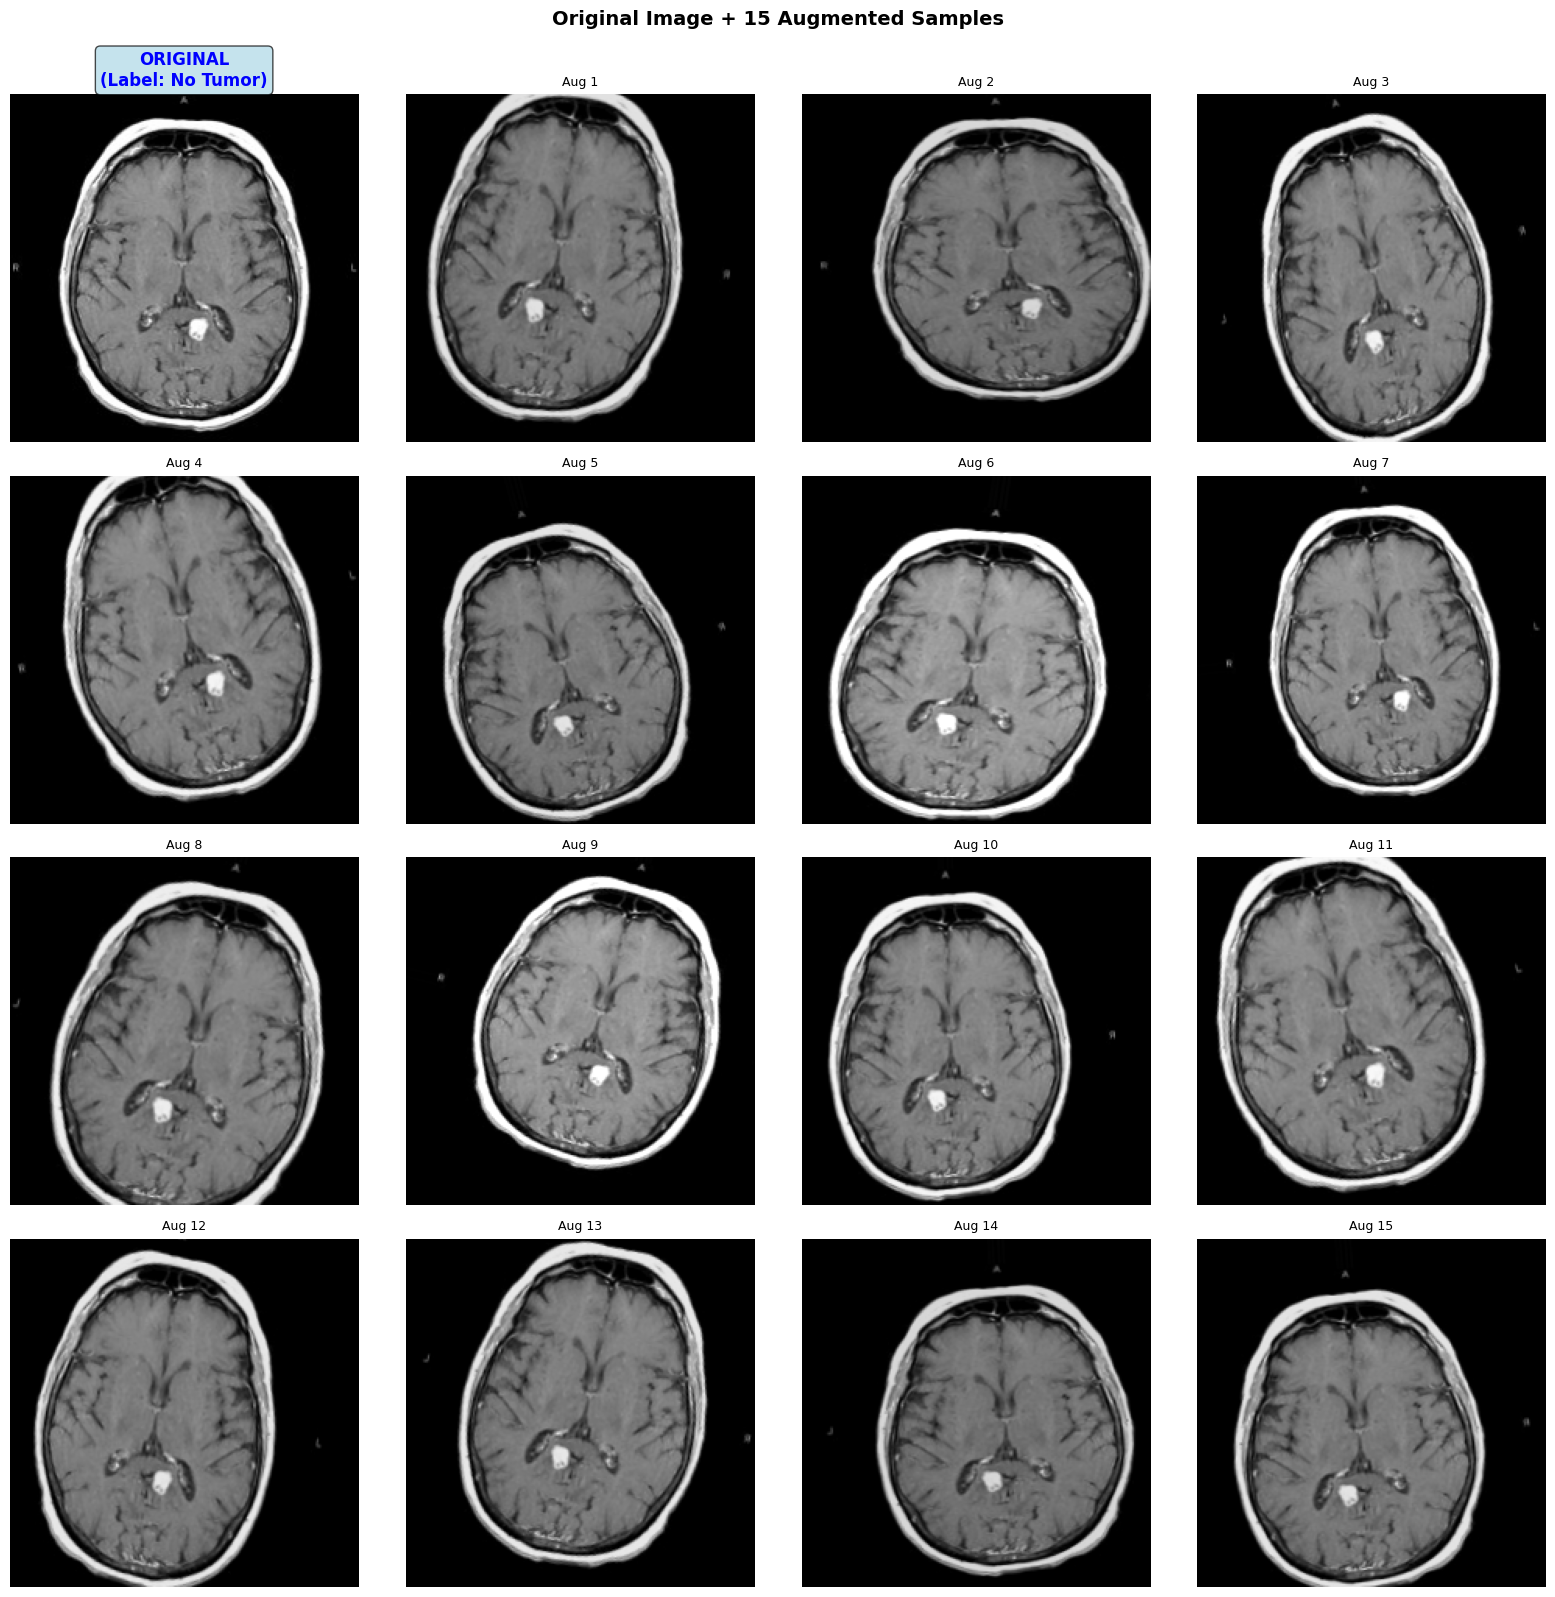

In [49]:
sample_idx = np.random.randint(0, len(X_train))
sample_img = X_train[sample_idx]
single_img = X_train[sample_idx:sample_idx+1]

num_preview = 15
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

axes[0].imshow(sample_img.astype('uint8'))
axes[0].set_title(f'ORIGINAL\n(Label: {["No Tumor", "Tumor"][int(y_train_arr[sample_idx])]})', 
                 fontweight='bold', fontsize=12, color='blue', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[0].axis('off')

# augmented samples
i = 1
for aug_img in aug_cnn.flow(single_img, batch_size=1):
    axes[i].imshow((aug_img[0] * 255).astype('uint8'))
    axes[i].set_title(f'Aug {i}', fontsize=9)
    axes[i].axis('off')
    i += 1
    
    if i > num_preview:
        break

for j in range(i, len(axes)):
    axes[j].axis('off')

plt.suptitle('Original Image + 15 Augmented Samples', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


In [50]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_preprocess

# Custom CNN: X_train stays [0-255] because aug_cnn has rescale=1./255
# Val/Test for CNN: manually scale to [0-1]
X_train_norm = X_train.astype('float32') 
X_val_norm   = X_val.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32') / 255.0

# Pretrained model preprocessing (expects float input in [0-255] range)
X_val_vgg     = vgg16_preprocess(X_val.astype('float32').copy())
X_test_vgg    = vgg16_preprocess(X_test.astype('float32').copy())

X_val_resnet  = resnet50_preprocess(X_val.astype('float32').copy())
X_test_resnet = resnet50_preprocess(X_test.astype('float32').copy())

X_val_eff     = eff_preprocess(X_val.astype('float32').copy())
X_test_eff    = eff_preprocess(X_test.astype('float32').copy())

X_val_mob     = mob_preprocess(X_val.astype('float32').copy())
X_test_mob    = mob_preprocess(X_test.astype('float32').copy())

print(f"X_train_norm : [{X_train_norm.min():.0f}, {X_train_norm.max():.0f}]  (aug_cnn will rescale to 0-1)")
print(f"X_val_norm   : [{X_val_norm.min():.3f}, {X_val_norm.max():.3f}]")
print(f"X_test_norm  : [{X_test_norm.min():.3f}, {X_test_norm.max():.3f}]")
print(f"X_val_vgg    : [{X_val_vgg.min():.1f}, {X_val_vgg.max():.1f}]")
print(f"X_val_mob    : [{X_val_mob.min():.3f}, {X_val_mob.max():.3f}]")


X_train_norm : [0, 255]  (aug_cnn will rescale to 0-1)
X_val_norm   : [0.000, 1.000]
X_test_norm  : [0.000, 1.000]
X_val_vgg    : [-123.7, 151.1]
X_val_mob    : [-1.000, 1.000]


# 4 - Utility Functions

In [51]:
def evaluate_model(model, X_test, y_test, model_name):
    """Comprehensive model evaluation with medical imaging metrics."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # == recall of positive class
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0

    metrics = {
        'model_name': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_pred_prob[:, 1]),
        'specificity': specificity,
        'sensitivity': sensitivity,
        'npv': npv,
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob
    }
    return metrics

def plot_confusion_matrix(y_true, y_pred, model_name):
    """Plot confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix - {model_name}', fontweight='bold', fontsize=12)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

def plot_roc_curve(y_true, y_pred_prob, model_name):
    """Plot ROC curve"""
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob[:, 1])
    roc_auc = roc_auc_score(y_true, y_pred_prob[:, 1])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{model_name} (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=11)
    plt.ylabel('True Positive Rate', fontsize=11)
    plt.title(f'ROC Curve - {model_name}', fontweight='bold', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_training_history(history, model_name):
    """Plot training history"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title(f'Accuracy - {model_name}', fontweight='bold', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title(f'Loss - {model_name}', fontweight='bold', fontsize=12)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def print_classification_report(y_true, y_pred, model_name):
    print(f"\nClassification Report - {model_name}\n")
    print(classification_report(y_true, y_pred,
                               target_names=['No Tumor', 'Tumor'],
                               digits=4))

def create_results_dataframe(all_models_metrics):
    """Create comparison dataframe with medical imaging metrics."""
    results = []
    for m in all_models_metrics:
        results.append({
            'Model': m['model_name'],
            'Accuracy': f"{m['accuracy']:.4f}",
            'Precision': f"{m['precision']:.4f}",
            'Recall': f"{m['recall']:.4f}",
            'F1-Score': f"{m['f1']:.4f}",
            'ROC-AUC': f"{m['roc_auc']:.4f}",
            'Sensitivity': f"{m.get('sensitivity', m['recall']):.4f}",
            'Specificity': f"{m.get('specificity', 0):.4f}",
            'NPV': f"{m.get('npv', 0):.4f}",
        })
    return pd.DataFrame(results)

def plot_metrics_comparison(all_models_metrics):
    """Compare all models metrics"""
    metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    model_names = [m['model_name'] for m in all_models_metrics]

    x = np.arange(len(metrics_names))
    width = 0.15

    fig, ax = plt.subplots(figsize=(14, 6))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, model_metrics in enumerate(all_models_metrics):
        values = [model_metrics[m] for m in metrics_names]
        ax.bar(x + i*width, values, width, label=model_names[i], color=colors[i])

    ax.set_xlabel('Metrics', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(x + width * 2)
    ax.set_xticklabels(metrics_names)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, 1.05])

    plt.tight_layout()
    plt.show()

def plot_all_roc_curves(all_models_metrics, y_test):
    """Plot all ROC curves overlay"""
    plt.figure(figsize=(10, 8))

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, model_metrics in enumerate(all_models_metrics):
        fpr, tpr, _ = roc_curve(y_test, model_metrics['y_pred_prob'][:, 1])
        roc_auc = model_metrics['roc_auc']
        plt.plot(fpr, tpr, linewidth=2.5,
                label=f"{model_metrics['model_name']} (AUC = {roc_auc:.4f})",
                color=colors[i])

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=11)
    plt.ylabel('True Positive Rate', fontsize=11)
    plt.title('ROC Curves - All Models Comparison', fontweight='bold', fontsize=13)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


In [55]:
from sklearn.model_selection import StratifiedKFold

# Combined trainval pool for k-fold (raw float [0,255])
X_trainval  = np.concatenate([X_train, X_val], axis=0)
y_trainval  = np.concatenate([y_train_arr, y_val_arr], axis=0)
print(f"Trainval pool: {X_trainval.shape}  "
      f"(tumor: {int(y_trainval.sum())}, no-tumor: {int(len(y_trainval) - y_trainval.sum())})")


def run_kfold_training(train_fn, X_trainval_raw, y_trainval,
                       X_test_eval, y_test,
                       val_preprocess_fn, aug_generator,
                       model_name, k=5, **train_kwargs):
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_metrics, fold_histories, fold_models = [], [], []

    for fold_idx, (tr_idx, vl_idx) in enumerate(
            skf.split(X_trainval_raw, y_trainval.astype(int)), 1):
        print(f"\n{model_name} — Fold {fold_idx}/{k}\n")
        X_tr = X_trainval_raw[tr_idx]
        y_tr = y_trainval[tr_idx]
        X_vl = val_preprocess_fn(X_trainval_raw[vl_idx].astype('float32').copy())
        y_vl = y_trainval[vl_idx]

        model, history = train_fn(
            X_tr, y_tr, X_vl, y_vl,
            aug_generator=aug_generator, **train_kwargs
        )
        m = evaluate_model(model, X_test_eval, y_test, f"{model_name} F{fold_idx}")
        print(f"  Fold {fold_idx}:  acc={m['accuracy']:.4f}  "
              f"f1={m['f1']:.4f}  auc={m['roc_auc']:.4f}")
        fold_metrics.append(m)
        fold_histories.append(history)
        fold_models.append(model)

    keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    avg  = {k_: float(np.mean([m[k_] for m in fold_metrics])) for k_ in keys}
    std  = {k_: float(np.std( [m[k_] for m in fold_metrics])) for k_ in keys}

    print(f"\n{model_name} — K-Fold Summary ({k} folds)\n")
    for k_ in keys:
        print(f"  {k_:10s}: {avg[k_]:.4f} ± {std[k_]:.4f}")

    best_idx     = int(np.argmax([m['accuracy'] for m in fold_metrics]))
    best_model   = fold_models[best_idx]
    best_history = fold_histories[best_idx]
    best_metrics = dict(fold_metrics[best_idx])
    best_metrics['model_name']         = model_name
    best_metrics['kfold_avg_accuracy'] = avg['accuracy']
    best_metrics['kfold_std_accuracy'] = std['accuracy']
    best_metrics['kfold_avg_f1']       = avg['f1']
    best_metrics['kfold_std_f1']       = std['f1']
    print(f"\n  Best fold: {best_idx+1}  (acc={best_metrics['accuracy']:.4f})")
    return best_model, best_history, best_metrics

Trainval pool: (215, 224, 224, 3)  (tumor: 132, no-tumor: 83)


# 5 - Model Training & Evaluation

### 5.1 - CNN

In [53]:
def build_custom_cnn_model(input_shape=(224, 224, 3), num_classes=2):
    """Build efficient custom CNN model - smaller to prevent overfitting on small dataset"""
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GroupNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GroupNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.GroupNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.GroupNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.GroupNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.GroupNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4 

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.GroupNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.GroupNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def train_custom_cnn_model(X_train, y_train, X_val, y_val, aug_generator=None, epochs=100, batch_size=16):
    """Train custom CNN with proper augmentation and class weighting"""
    model = build_custom_cnn_model()

    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    class_weights = {
        int(cls): len(y_train) / (len(unique_classes) * count)
        for cls, count in zip(unique_classes, class_counts)
    }


    model.compile(
        optimizer=Adam(learning_rate=5e-2),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.3, patience=10, min_lr=1e-6, verbose=1)
    ]

    if aug_generator is not None:
        steps_per_epoch = max(1, len(X_train) // batch_size)
        history = model.fit(
            aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
            validation_data=(X_val, y_val),
            steps_per_epoch=steps_per_epoch,
            epochs=epochs,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )
    else:
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            class_weight=class_weights,
            verbose=1
        )

    return model, history

all_models_metrics = []
all_models = {}



Custom CNN — Fold 1/5
Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 519ms/step - accuracy: 0.5064 - loss: 1.9688 - val_accuracy: 0.3953 - val_loss: 1.2346 - learning_rate: 0.0500
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2500 - loss: 1.7608 - val_accuracy: 0.3953 - val_loss: 1.0427 - learning_rate: 0.0500
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 393ms/step - accuracy: 0.5577 - loss: 0.9016 - val_accuracy: 0.5116 - val_loss: 0.6744 - learning_rate: 0.0500
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2500 - loss: 1.1500 - val_accuracy: 0.6047 - val_loss: 0.6269 - learning_rate: 0.0500
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 444ms/step - accuracy: 0.5449 - loss: 0.9570 - val_accuracy: 0.3953 - val_loss: 0.8698 - learning_rate: 0.0500
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2500 - loss: 0.9343 - val_accuracy: 0.3953 - val_loss: 1.8134 - learning_rate: 0.0500
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 369ms/step - accura

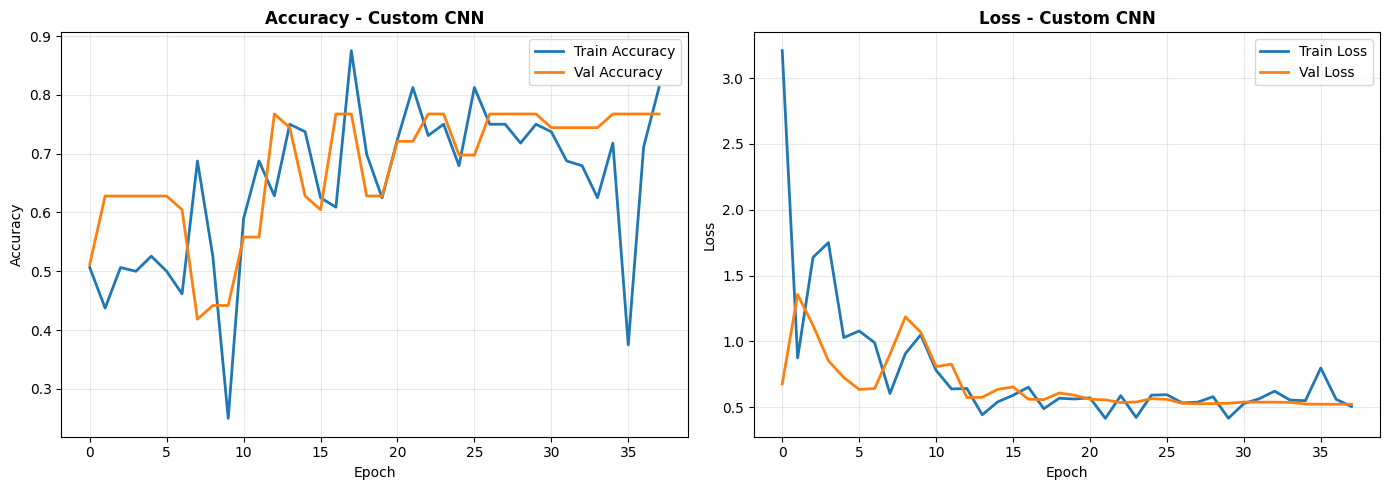

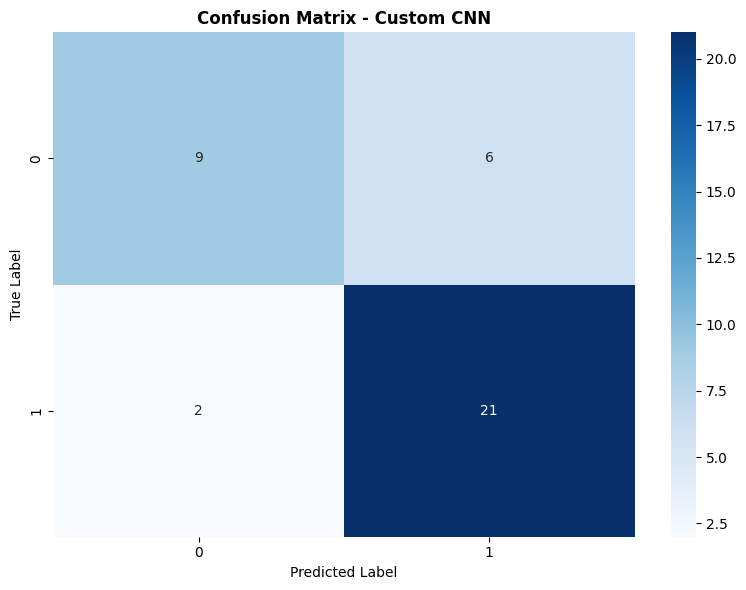

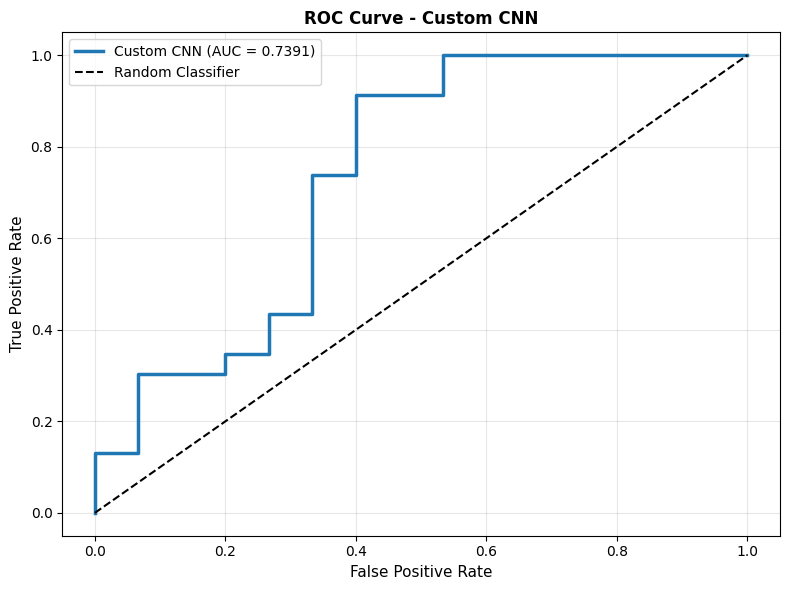


Classification Report - Custom CNN

              precision    recall  f1-score   support

    No Tumor     0.8182    0.6000    0.6923        15
       Tumor     0.7778    0.9130    0.8400        23

    accuracy                         0.7895        38
   macro avg     0.7980    0.7565    0.7662        38
weighted avg     0.7937    0.7895    0.7817        38



In [54]:
model_cnn, history_cnn, metrics_cnn = run_kfold_training(
    train_custom_cnn_model,
    X_trainval, y_trainval,
    X_test_norm, y_test_arr,
    val_preprocess_fn=lambda x: x / 255.0,
    aug_generator=aug_cnn,
    model_name="Custom CNN", k=5,
    epochs=100, batch_size=16,
)
all_models_metrics.append(metrics_cnn)
all_models['Custom CNN'] = model_cnn

print(f"\nTest Metrics - Custom CNN (best fold)")
print(f"   Accuracy:  {metrics_cnn['accuracy']:.4f}")
print(f"   Precision: {metrics_cnn['precision']:.4f}")
print(f"   Recall:    {metrics_cnn['recall']:.4f}")
print(f"   F1-Score:  {metrics_cnn['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_cnn['roc_auc']:.4f}")
print(f"   K-Fold Avg Acc: {metrics_cnn['kfold_avg_accuracy']:.4f} ± {metrics_cnn['kfold_std_accuracy']:.4f}")

plot_training_history(history_cnn, "Custom CNN")
plot_confusion_matrix(y_test_arr, metrics_cnn['y_pred'], "Custom CNN")
plot_roc_curve(y_test_arr, metrics_cnn['y_pred_prob'], "Custom CNN")
print_classification_report(y_test_arr, metrics_cnn['y_pred'], "Custom CNN")

### 5.2 - VGG16

In [56]:
def build_vgg16_model(input_shape=(224, 224, 3), num_classes=2):
    """VGG16 — unfreeze only block5 (last conv block). Lightweight classifier head."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    base_model = tf.keras.applications.VGG16(
        weights='imagenet', include_top=False, input_shape=input_shape
    )

    for layer in base_model.layers:
        layer.trainable = layer.name.startswith('block5')

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def train_vgg16_model(X_train, y_train, X_val, y_val, aug_generator=None,
                     epochs=80, batch_size=16):
    model = build_vgg16_model()

    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    class_weights = {
        int(cls): len(y_train) / (len(unique_classes) * count)
        for cls, count in zip(unique_classes, class_counts)
    }

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3,
                          patience=6, min_lr=1e-7, verbose=1)
    ]

    steps_per_epoch = max(1, len(X_train) // batch_size)
    history = model.fit(
        aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
        validation_data=(X_val, y_val),
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )
    return model, history


VGG16 — Fold 1/5

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 391ms/step - accuracy: 0.5500 - loss: 2.2834 - val_accuracy: 0.7907 - val_loss: 0.4569 - learning_rate: 1.0000e-04
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6667 - loss: 0.5356 - val_accuracy: 0.7907 - val_loss: 0.4517 - learning_rate: 1.0000e-04
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 297ms/step - accuracy: 0.7051 - loss: 0.6327 - val_accuracy: 0.7674 - val_loss: 0.4222 - learning_rate: 1.0000e-04
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5625 - loss: 0.6675 - val_accuracy: 0.7674 - val_loss: 0.4235 - learning_rate: 1.0000e-04
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 297ms/step - accuracy: 0.8000 - loss: 0.4628 - val_accuracy: 0.8140 - val_loss: 0.4212 - learning_rate: 1.0000e-04
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7500 - loss: 0.4399 - val_accuracy: 0.7907 - val_loss: 0.4419 - learning_rate: 1.0000e-

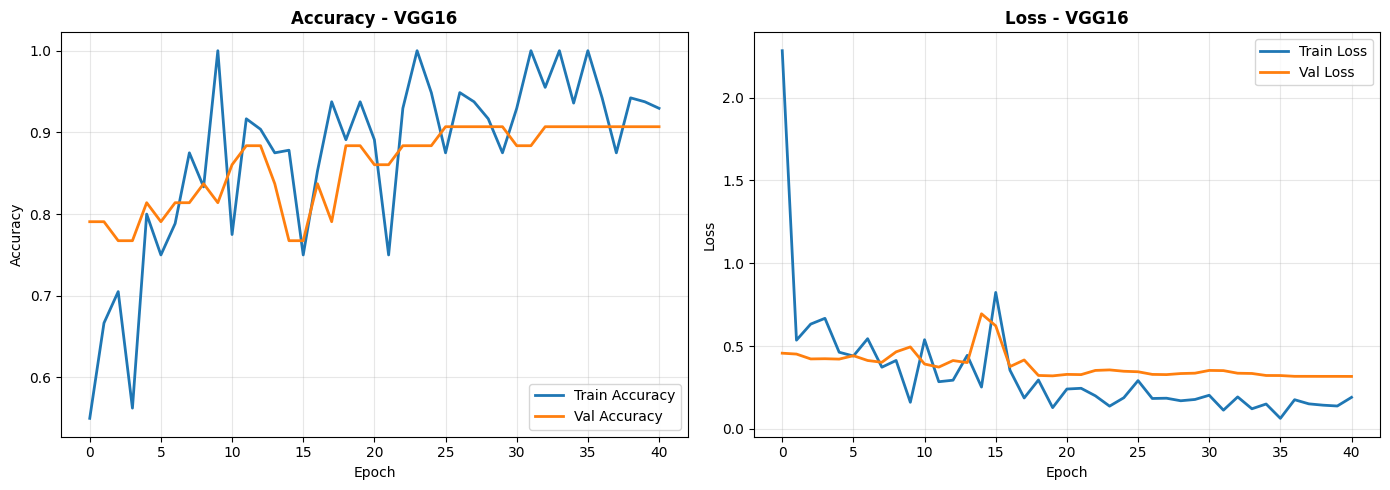

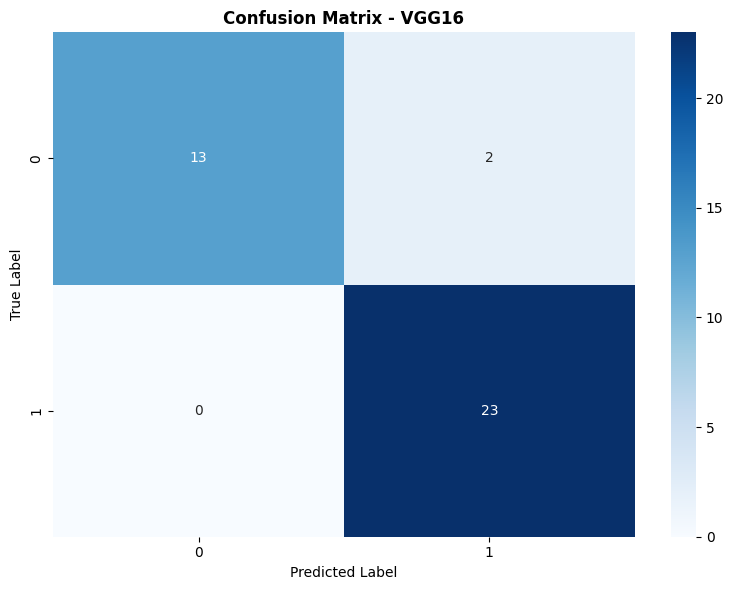

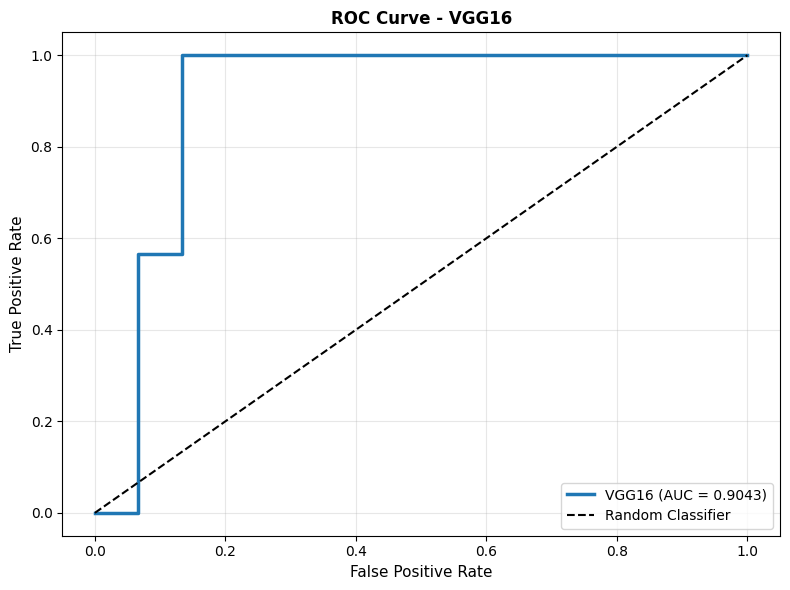


Classification Report - VGG16

              precision    recall  f1-score   support

    No Tumor     1.0000    0.8667    0.9286        15
       Tumor     0.9200    1.0000    0.9583        23

    accuracy                         0.9474        38
   macro avg     0.9600    0.9333    0.9435        38
weighted avg     0.9516    0.9474    0.9466        38



In [57]:
model_vgg, history_vgg, metrics_vgg = run_kfold_training(
    train_vgg16_model,
    X_trainval, y_trainval,
    X_test_vgg, y_test_arr,
    val_preprocess_fn=vgg16_preprocess,
    aug_generator=aug_vgg,
    model_name="VGG16", k=5,
    epochs=80, batch_size=16,
)
all_models_metrics.append(metrics_vgg)
all_models['VGG16'] = model_vgg

print(f"\nTest Metrics - VGG16 (best fold)")
print(f"   Accuracy:  {metrics_vgg['accuracy']:.4f}")
print(f"   Precision: {metrics_vgg['precision']:.4f}")
print(f"   Recall:    {metrics_vgg['recall']:.4f}")
print(f"   F1-Score:  {metrics_vgg['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_vgg['roc_auc']:.4f}")
print(f"   K-Fold Avg Acc: {metrics_vgg['kfold_avg_accuracy']:.4f} ± {metrics_vgg['kfold_std_accuracy']:.4f}")

plot_training_history(history_vgg, "VGG16")
plot_confusion_matrix(y_test_arr, metrics_vgg['y_pred'], "VGG16")
plot_roc_curve(y_test_arr, metrics_vgg['y_pred_prob'], "VGG16")
print_classification_report(y_test_arr, metrics_vgg['y_pred'], "VGG16")

### 5.3 - ResNet50

In [58]:
def build_resnet50_model(input_shape=(224, 224, 3), num_classes=2):
    """ResNet50 — frozen backbone + lightweight head."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    base_model = tf.keras.applications.ResNet50(
        weights='imagenet', include_top=False, input_shape=input_shape
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

def train_resnet50_model(X_train, y_train, X_val, y_val, aug_generator=None,
                        epochs=80, batch_size=16):
    model = build_resnet50_model()

    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    class_weights = {
        int(cls): len(y_train) / (len(unique_classes) * count)
        for cls, count in zip(unique_classes, class_counts)
    }

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3,
                          patience=6, min_lr=1e-7, verbose=1)
    ]

    steps_per_epoch = max(1, len(X_train) // batch_size)
    history = model.fit(
        aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
        validation_data=(X_val, y_val),
        steps_per_epoch=steps_per_epoch,
        epochs=epochs,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1
    )
    return model, history


ResNet50 — Fold 1/5

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 629ms/step - accuracy: 0.6410 - loss: 0.8390 - val_accuracy: 0.7674 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8750 - loss: 0.4220 - val_accuracy: 0.7907 - val_loss: 0.4332 - learning_rate: 0.0010
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 282ms/step - accuracy: 0.8141 - loss: 0.4317 - val_accuracy: 0.8605 - val_loss: 0.3658 - learning_rate: 0.0010
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9375 - loss: 0.1455 - val_accuracy: 0.8372 - val_loss: 0.3627 - learning_rate: 0.0010
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step - accuracy: 0.8397 - loss: 0.5155 - val_accuracy: 0.8605 - val_loss: 0.3899 - learning_rate: 0.0010
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9375 - loss: 0.2047 - val_accuracy: 0.8605 - val_loss: 0.3917 - learning_rate: 0.0010
Epoch 7/80
10/10 

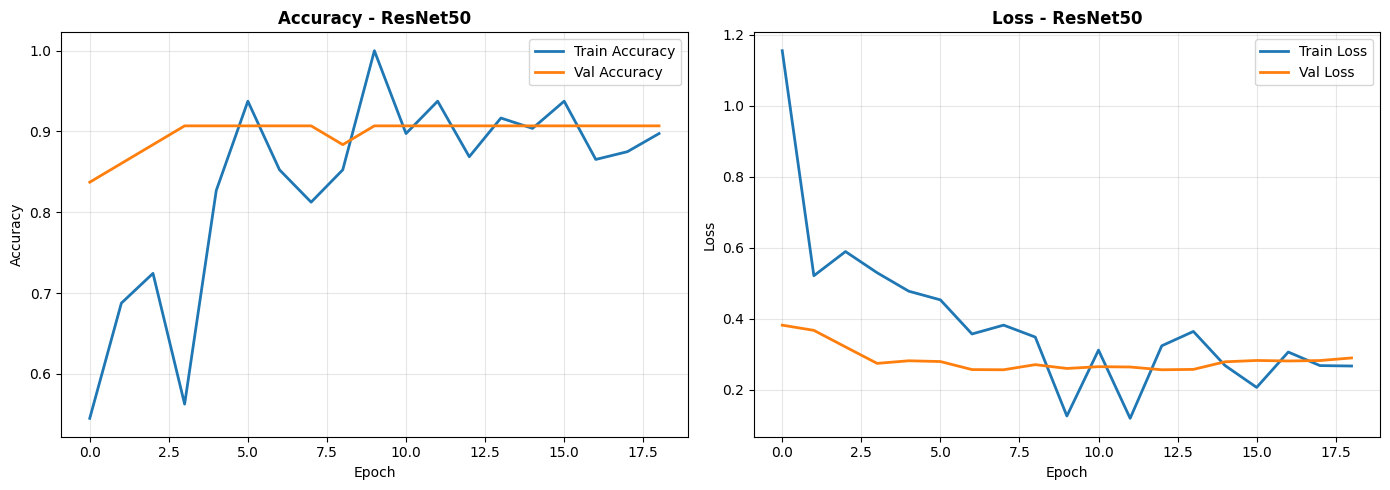

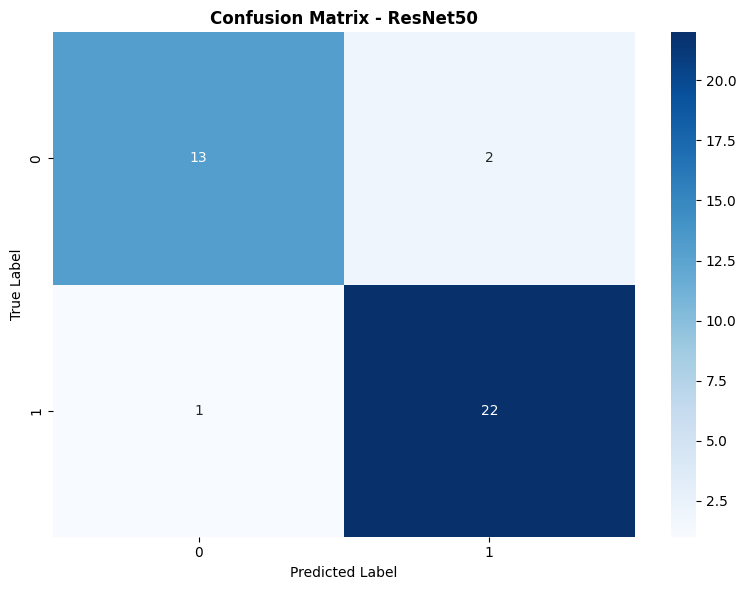

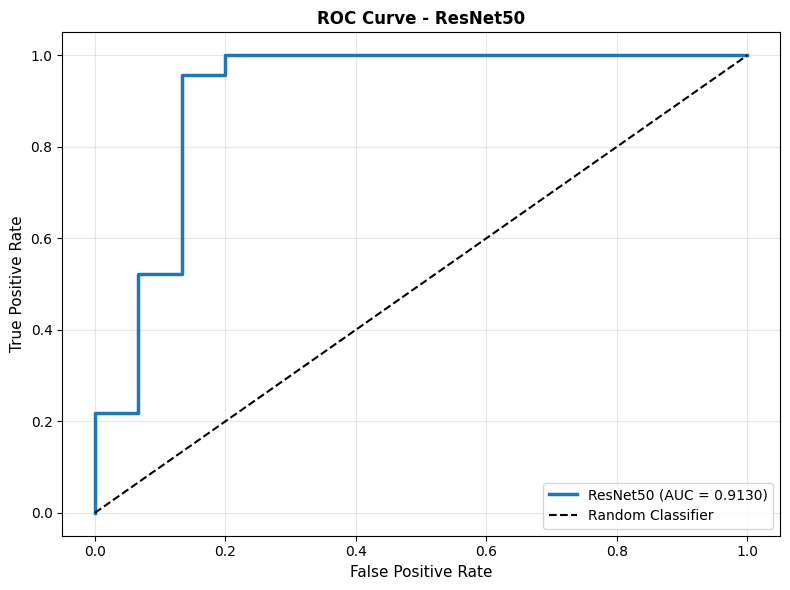


Classification Report - ResNet50

              precision    recall  f1-score   support

    No Tumor     0.9286    0.8667    0.8966        15
       Tumor     0.9167    0.9565    0.9362        23

    accuracy                         0.9211        38
   macro avg     0.9226    0.9116    0.9164        38
weighted avg     0.9214    0.9211    0.9205        38



In [59]:
model_res, history_res, metrics_res = run_kfold_training(
    train_resnet50_model,
    X_trainval, y_trainval,
    X_test_resnet, y_test_arr,
    val_preprocess_fn=resnet50_preprocess,
    aug_generator=aug_resnet,
    model_name="ResNet50", k=5,
    epochs=80, batch_size=16,
)
all_models_metrics.append(metrics_res)
all_models['ResNet50'] = model_res

print(f"\nTest Metrics - ResNet50 (best fold)")
print(f"   Accuracy:  {metrics_res['accuracy']:.4f}")
print(f"   Precision: {metrics_res['precision']:.4f}")
print(f"   Recall:    {metrics_res['recall']:.4f}")
print(f"   F1-Score:  {metrics_res['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_res['roc_auc']:.4f}")
print(f"   K-Fold Avg Acc: {metrics_res['kfold_avg_accuracy']:.4f} ± {metrics_res['kfold_std_accuracy']:.4f}")

plot_training_history(history_res, "ResNet50")
plot_confusion_matrix(y_test_arr, metrics_res['y_pred'], "ResNet50")
plot_roc_curve(y_test_arr, metrics_res['y_pred_prob'], "ResNet50")
print_classification_report(y_test_arr, metrics_res['y_pred'], "ResNet50")

### 5.4 - EfficientNetB0

In [60]:
def build_efficientnet_model(input_shape=(224, 224, 3), num_classes=2):
    """EfficientNetB0 — lightweight head. Returns (model, base_model) so the training
    loop can unfreeze top layers for fine-tuning after head warmup."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    base_model = tf.keras.applications.EfficientNetB0(
        weights='imagenet', include_top=False, input_shape=input_shape
    )
    base_model.trainable = False  # Stage 1: frozen backbone

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model, base_model

def train_efficientnet_model(X_train, y_train, X_val, y_val, aug_generator=None,
                            epochs=80, batch_size=16):
    model, base_model = build_efficientnet_model()

    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    class_weights = {
        int(cls): len(y_train) / (len(unique_classes) * count)
        for cls, count in zip(unique_classes, class_counts)
    }

    steps_per_epoch = max(1, len(X_train) // batch_size)
    callbacks_stage1 = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3,
                          patience=5, min_lr=1e-6, verbose=1)
    ]

    # ----- Stage 1: head warmup (backbone frozen) -----
    print("Stage 1: head warmup (backbone frozen)")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    warmup_epochs = min(15, epochs // 3)
    hist1 = model.fit(
        aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
        validation_data=(X_val, y_val),
        steps_per_epoch=steps_per_epoch,
        epochs=warmup_epochs,
        callbacks=callbacks_stage1,
        class_weight=class_weights,
        verbose=1
    )

    # ----- Stage 2: unfreeze top 20 layers, fine-tune -----
    print("\nStage 2: fine-tuning top backbone layers")
    base_model.trainable = True
    for layer in base_model.layers[:-20]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks_stage2 = [
        EarlyStopping(monitor='val_accuracy', mode='max', patience=12,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3,
                          patience=5, min_lr=1e-7, verbose=1)
    ]
    hist2 = model.fit(
        aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
        validation_data=(X_val, y_val),
        steps_per_epoch=steps_per_epoch,
        epochs=epochs - warmup_epochs,
        callbacks=callbacks_stage2,
        class_weight=class_weights,
        verbose=1
    )

    class MergedHistory:
        def __init__(self, h1, h2):
            self.history = {
                k: h1.history.get(k, []) + h2.history.get(k, [])
                for k in set(h1.history) | set(h2.history)
            }
    return model, MergedHistory(hist1, hist2)


EfficientNetB0 — Fold 1/5

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Stage 1: head warmup (backbone frozen)
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 554ms/step - accuracy: 0.6859 - loss: 0.6046 - val_accuracy: 0.7674 - val_loss: 0.4372 - learning_rate: 0.0010
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8125 - loss: 0.5002 - val_accuracy: 0.8372 - val_loss: 0.4127 - learning_rate: 0.0010
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 348ms/step - accuracy: 0.8526 - loss: 0.4028 - val_accuracy: 0.8372 - val_loss: 0.3379 - learning_rate: 0.0010
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.1352 - val_accuracy: 0.8372 - val_loss: 0.3427 - learning_rate: 0.0010
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step - accuracy: 0.8397 - loss: 0.3835 - val_accuracy: 0.8605 - val_loss: 0.2978 - learning_rate: 0.0010
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.2666 - val_accuracy: 0.8605 - val_loss: 0.2

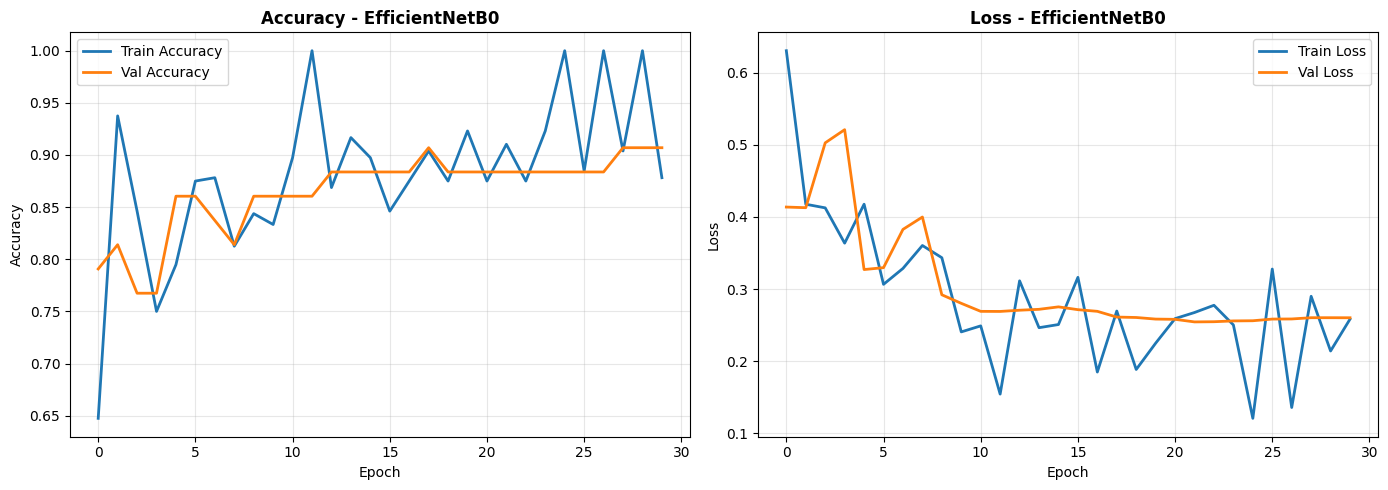

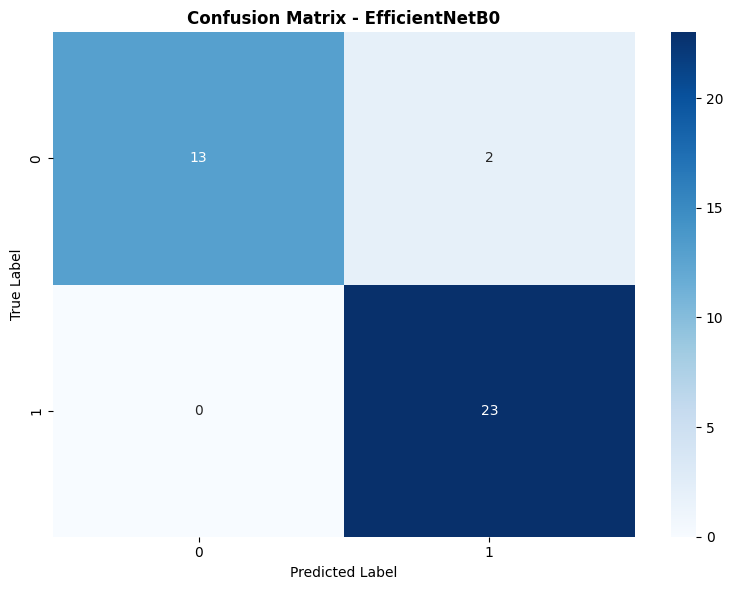

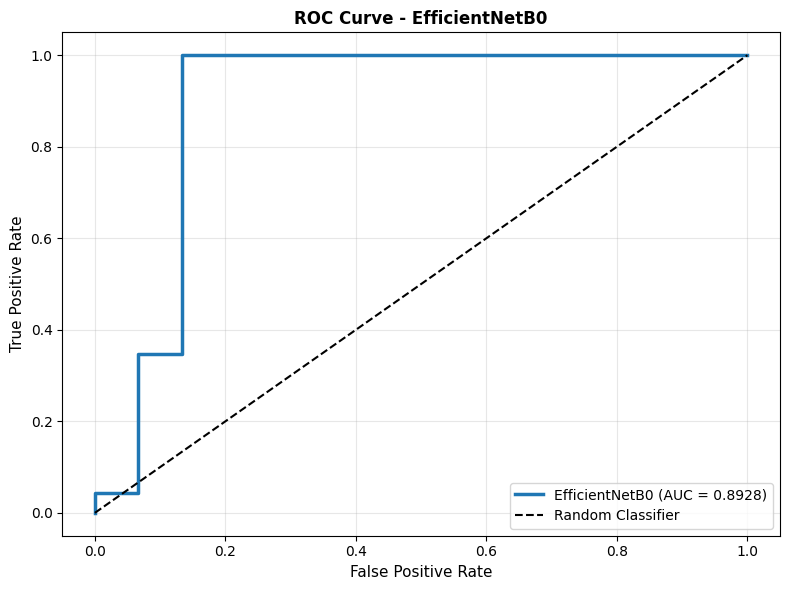


Classification Report - EfficientNetB0

              precision    recall  f1-score   support

    No Tumor     1.0000    0.8667    0.9286        15
       Tumor     0.9200    1.0000    0.9583        23

    accuracy                         0.9474        38
   macro avg     0.9600    0.9333    0.9435        38
weighted avg     0.9516    0.9474    0.9466        38



In [61]:
model_eff, history_eff, metrics_eff = run_kfold_training(
    train_efficientnet_model,
    X_trainval, y_trainval,
    X_test_eff, y_test_arr,
    val_preprocess_fn=eff_preprocess,
    aug_generator=aug_eff,
    model_name="EfficientNetB0", k=5,
    epochs=80, batch_size=16,
)
all_models_metrics.append(metrics_eff)
all_models['EfficientNetB0'] = model_eff

print(f"\nTest Metrics - EfficientNetB0 (best fold)")
print(f"   Accuracy:  {metrics_eff['accuracy']:.4f}")
print(f"   Precision: {metrics_eff['precision']:.4f}")
print(f"   Recall:    {metrics_eff['recall']:.4f}")
print(f"   F1-Score:  {metrics_eff['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_eff['roc_auc']:.4f}")
print(f"   K-Fold Avg Acc: {metrics_eff['kfold_avg_accuracy']:.4f} ± {metrics_eff['kfold_std_accuracy']:.4f}")

plot_training_history(history_eff, "EfficientNetB0")
plot_confusion_matrix(y_test_arr, metrics_eff['y_pred'], "EfficientNetB0")
plot_roc_curve(y_test_arr, metrics_eff['y_pred_prob'], "EfficientNetB0")
print_classification_report(y_test_arr, metrics_eff['y_pred'], "EfficientNetB0")

### 5.5 - MobileNetV2

In [62]:
def build_mobilenet_model(input_shape=(224, 224, 3), num_classes=2):
    """MobileNetV2 — lightweight head. Two-stage: head warmup, then unfreeze top 30%."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    base_model = tf.keras.applications.MobileNetV2(
        weights='imagenet', include_top=False, input_shape=input_shape
    )
    base_model.trainable = False

    model = keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model, base_model

def train_mobilenet_model(X_train, y_train, X_val, y_val, aug_generator=None,
                         epochs=80, batch_size=16):
    model, base_model = build_mobilenet_model()

    unique_classes, class_counts = np.unique(y_train, return_counts=True)
    class_weights = {
        int(cls): len(y_train) / (len(unique_classes) * count)
        for cls, count in zip(unique_classes, class_counts)
    }

    steps_per_epoch = max(1, len(X_train) // batch_size)

    # ----- Stage 1: head warmup -----
    print("Stage 1: head warmup (backbone frozen)")
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    warmup_epochs = min(15, epochs // 3)
    hist1 = model.fit(
        aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
        validation_data=(X_val, y_val),
        steps_per_epoch=steps_per_epoch,
        epochs=warmup_epochs,
        callbacks=[
            EarlyStopping(monitor='val_accuracy', mode='max', patience=10,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3,
                              patience=5, min_lr=1e-6, verbose=1)
        ],
        class_weight=class_weights,
        verbose=1
    )

    # ----- Stage 2: unfreeze last 30% -----
    print("\nStage 2: fine-tuning top 30% of backbone")
    base_model.trainable = True
    cutoff = int(len(base_model.layers) * 0.70)
    for layer in base_model.layers[:cutoff]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    hist2 = model.fit(
        aug_generator.flow(X_train, y_train, batch_size=batch_size, seed=SEED),
        validation_data=(X_val, y_val),
        steps_per_epoch=steps_per_epoch,
        epochs=epochs - warmup_epochs,
        callbacks=[
            EarlyStopping(monitor='val_accuracy', mode='max', patience=12,
                          restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3,
                              patience=5, min_lr=1e-7, verbose=1)
        ],
        class_weight=class_weights,
        verbose=1
    )

    class MergedHistory:
        def __init__(self, h1, h2):
            self.history = {
                k: h1.history.get(k, []) + h2.history.get(k, [])
                for k in set(h1.history) | set(h2.history)
            }
    return model, MergedHistory(hist1, hist2)


MobileNetV2 — Fold 1/5

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Stage 1: head warmup (backbone frozen)
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 421ms/step - accuracy: 0.6474 - loss: 0.7003 - val_accuracy: 0.7674 - val_loss: 0.4521 - learning_rate: 0.0010
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6875 - loss: 0.5714 - val_accuracy: 0.8140 - val_loss: 0.4989 - learning_rate: 0.0010
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.7564 - loss: 0.6538 - val_accuracy: 0.7674 - val_loss: 0.5016 - learning_rate: 0.0010
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8125 - loss: 0.4589 - val_accuracy: 0.6977 - val_loss: 0.5366 - learning_rate: 0.0010
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - accuracy: 0.7756 - loss: 0.4366 - val_accuracy: 0.9070 - val_loss: 0.3166 - learning_rate: 0.0010
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9375 - loss: 0.3025 - val_accuracy: 0.9070 - val_loss: 0.3175 - 

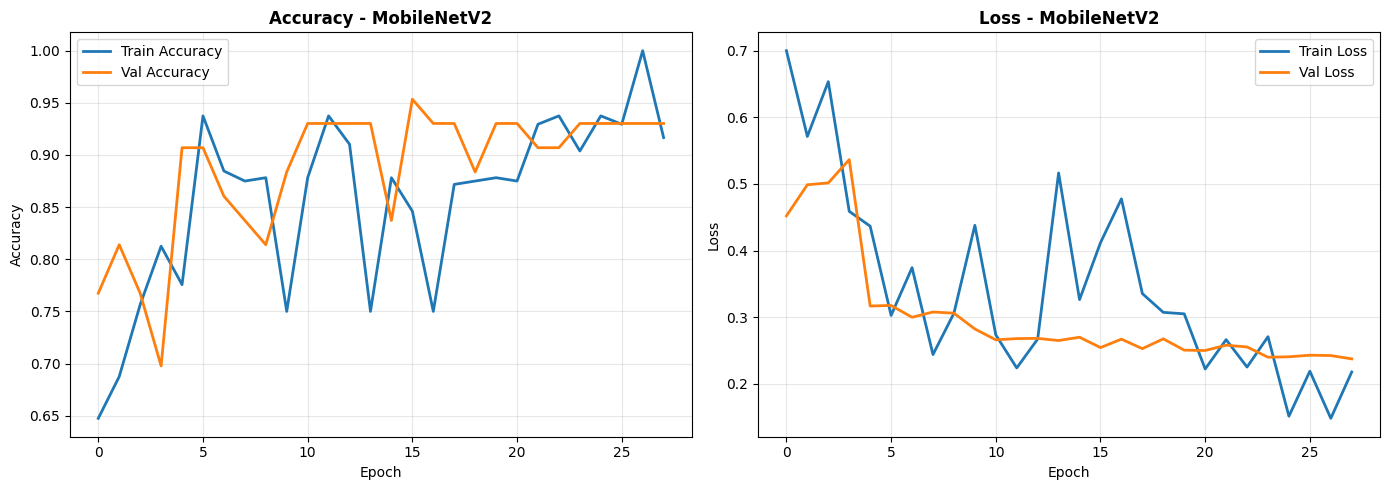

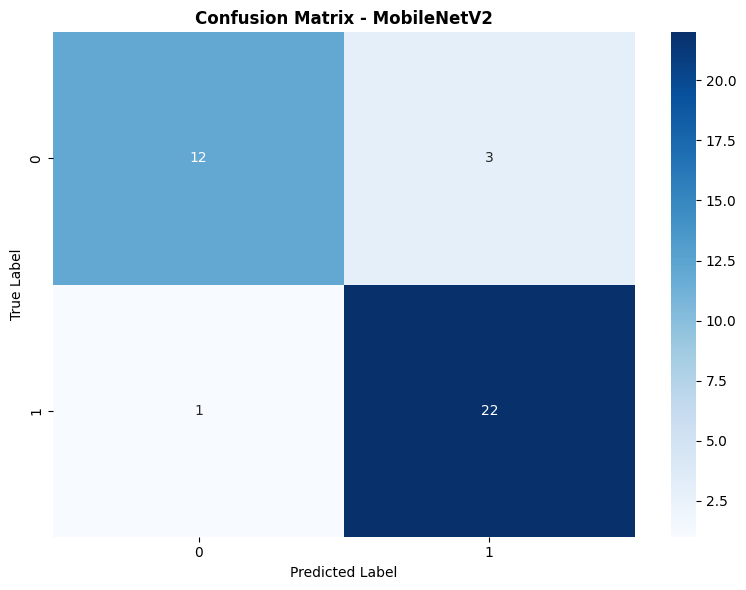

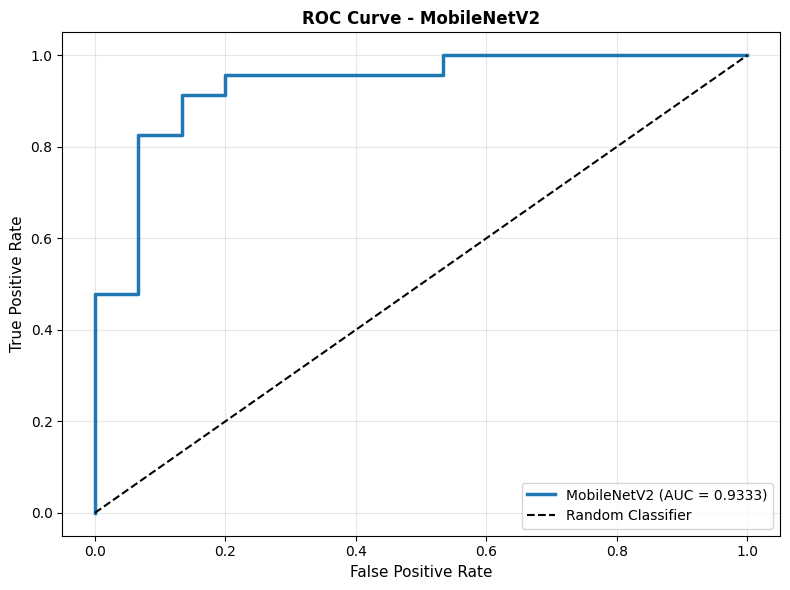


Classification Report - MobileNetV2

              precision    recall  f1-score   support

    No Tumor     0.9231    0.8000    0.8571        15
       Tumor     0.8800    0.9565    0.9167        23

    accuracy                         0.8947        38
   macro avg     0.9015    0.8783    0.8869        38
weighted avg     0.8970    0.8947    0.8932        38



In [63]:
model_mob, history_mob, metrics_mob = run_kfold_training(
    train_mobilenet_model,
    X_trainval, y_trainval,
    X_test_mob, y_test_arr,
    val_preprocess_fn=mob_preprocess,
    aug_generator=aug_mob,
    model_name="MobileNetV2", k=5,
    epochs=80, batch_size=16,
)
all_models_metrics.append(metrics_mob)
all_models['MobileNetV2'] = model_mob

print(f"\nTest Metrics - MobileNetV2 (best fold)")
print(f"   Accuracy:  {metrics_mob['accuracy']:.4f}")
print(f"   Precision: {metrics_mob['precision']:.4f}")
print(f"   Recall:    {metrics_mob['recall']:.4f}")
print(f"   F1-Score:  {metrics_mob['f1']:.4f}")
print(f"   ROC-AUC:   {metrics_mob['roc_auc']:.4f}")
print(f"   K-Fold Avg Acc: {metrics_mob['kfold_avg_accuracy']:.4f} ± {metrics_mob['kfold_std_accuracy']:.4f}")

plot_training_history(history_mob, "MobileNetV2")
plot_confusion_matrix(y_test_arr, metrics_mob['y_pred'], "MobileNetV2")
plot_roc_curve(y_test_arr, metrics_mob['y_pred_prob'], "MobileNetV2")
print_classification_report(y_test_arr, metrics_mob['y_pred'], "MobileNetV2")

# 6 - Final Comparative Analysis

 ==== ALL MODELS PERFORMANCE COMPARISON ====
         Model Accuracy Precision Recall F1-Score ROC-AUC Sensitivity Specificity    NPV
    Custom CNN   0.7895    0.7778 0.9130   0.8400  0.7391      0.9130      0.6000 0.8182
         VGG16   0.9474    0.9200 1.0000   0.9583  0.9043      1.0000      0.8667 1.0000
      ResNet50   0.9211    0.9167 0.9565   0.9362  0.9130      0.9565      0.8667 0.9286
EfficientNetB0   0.9474    0.9200 1.0000   0.9583  0.8928      1.0000      0.8667 1.0000
   MobileNetV2   0.8947    0.8800 0.9565   0.9167  0.9333      0.9565      0.8000 0.9231

Best Model (by F1): VGG16
   Accuracy:    0.9474
   F1-Score:    0.9583
   ROC-AUC:     0.9043
   Sensitivity: 1.0000
   Specificity: 0.8667


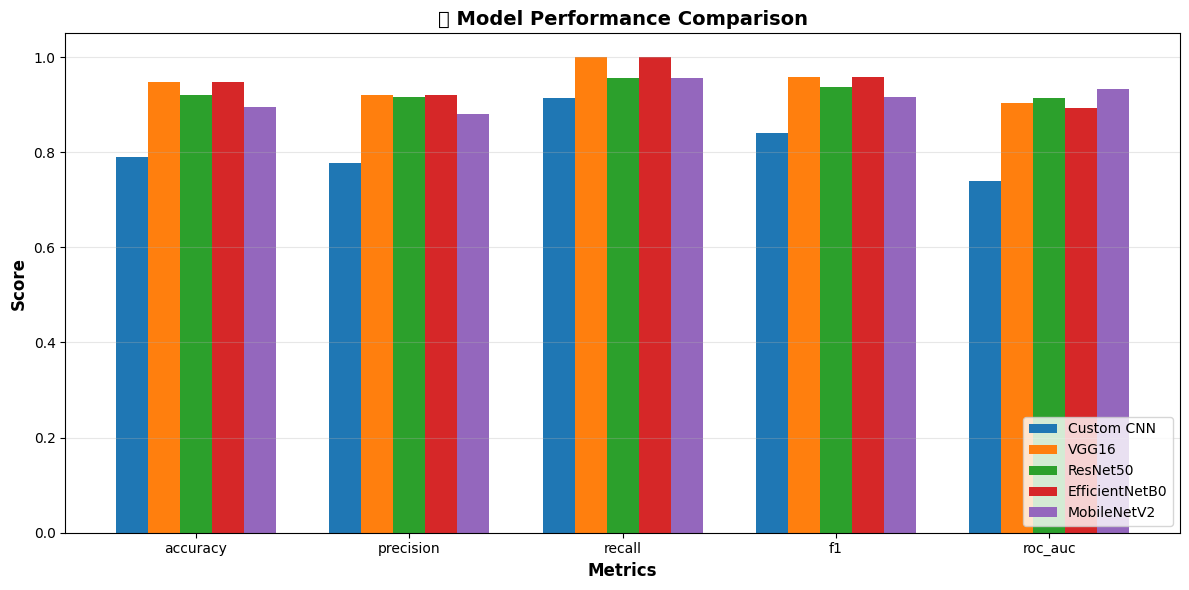

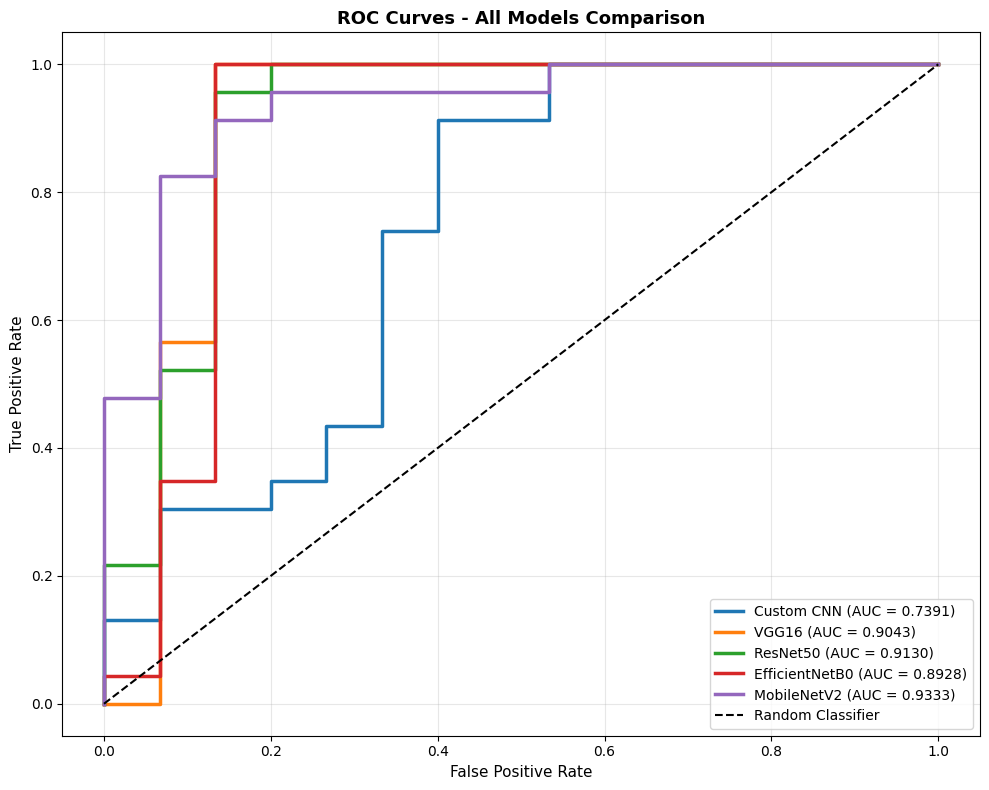

In [64]:
all_models_metrics = all_models_metrics[-5:]

results_df = create_results_dataframe(all_models_metrics)
print(" ==== ALL MODELS PERFORMANCE COMPARISON ====")
print(results_df.to_string(index=False))

# Find best model
# Medical imaging: prefer F1 (balances missed tumors vs. false alarms).
best_idx = np.argmax([m['f1'] for m in all_models_metrics])
best = all_models_metrics[best_idx]

print(f"\nBest Model (by F1): {best['model_name']}")
print(f"   Accuracy:    {best['accuracy']:.4f}")
print(f"   F1-Score:    {best['f1']:.4f}")
print(f"   ROC-AUC:     {best['roc_auc']:.4f}")
print(f"   Sensitivity: {best.get('sensitivity', best['recall']):.4f}")
print(f"   Specificity: {best.get('specificity', 0):.4f}")


fig, ax = plt.subplots(figsize=(12, 6))
metrics_names = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
model_names = [m['model_name'] for m in all_models_metrics]

x = np.arange(len(metrics_names))
width = 0.15

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for i, model_metrics in enumerate(all_models_metrics):
    values = [model_metrics[m] for m in metrics_names]
    ax.bar(x + i*width, values, width, label=model_names[i], color=colors[i % len(colors)])

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('🎯 Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(metrics_names)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
for i, model_metrics in enumerate(all_models_metrics):
    fpr, tpr, _ = roc_curve(y_test_arr, model_metrics['y_pred_prob'][:, 1])
    roc_auc = model_metrics['roc_auc']
    plt.plot(fpr, tpr, linewidth=2.5, 
            label=f"{model_metrics['model_name']} (AUC = {roc_auc:.4f})",
            color=colors[i % len(colors)])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curves - All Models Comparison', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()